In [19]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from scipy.stats import zscore

In [20]:
df = pd.read_csv("train.csv")

In [21]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape:
(891, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

In [22]:

print("\n================ Q1.1 — DATA INSPECTION ================")

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

# Show only columns with missing values
missing_table = missing_table[
    missing_table['Missing Values'] > 0
]

print("\nMissing Values Table:")
print(missing_table)


================ Q1.1 — DATA INSPECTION ================

Dataset Shape:
(891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values Table:
          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


In [26]:
print("\n================ Q1.2 — HANDLE AGE ================")

df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'] \
              .transform(lambda x: x.fillna(x.median()))

print("\nRemaining Missing Age Values:")
print(df['Age'].isna().sum())

print("\nMedian Ages Used:")
print(df.groupby(['Pclass', 'Sex'])['Age'].median())


================ Q1.2 — HANDLE AGE ================

Remaining Missing Age Values:
0

Median Ages Used:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


In [25]:

print("\n================ Q1.3 — HANDLE EMBARKED & FARE ================")

most_common_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common_embarked)


df['Fare'] = df.groupby('Pclass')['Fare'] \
               .transform(lambda x: x.fillna(x.median()))

print("\nMissing Embarked Values:")
print(df['Embarked'].isna().sum())

print("\nMissing Fare Values:")
print(df['Fare'].isna().sum())



================ Q1.3 — HANDLE EMBARKED & FARE ================

Missing Embarked Values:
0

Missing Fare Values:
0


In [27]:
print("\n================ Q1.4 — ENCODING ================")

df['Sex'] = df['Sex'].map({
    'male': 1,
    'female': 0
})

df['Embarked'] = df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

print("\nSex Value Counts:")
print(df['Sex'].value_counts())

print("\nEmbarked Value Counts:")
print(df['Embarked'].value_counts())



================ Q1.4 — ENCODING ================

Sex Value Counts:
Sex
1    577
0    314
Name: count, dtype: int64

Embarked Value Counts:
Embarked
0    646
1    168
2     77
Name: count, dtype: int64


In [29]:
print("\n================ Q1.5 — FEATURE ENGINEERING ================")

df['Title'] = df['Name'].str.extract(
    r' ([A-Za-z]+)\.',
    expand=False
)

df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')


df['Title'] = df['Title'].replace([
    'Lady', 'Countess', 'Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev',
    'Sir', 'Jonkheer', 'Dona'
], 'Rare')


title_mapping = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Rare': 5
}

df['Title'] = df['Title'].map(title_mapping)

df['Title'] = df['Title'].fillna(0)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("\nFeature Engineering Results:")
print(df[['Name', 'Title',
          'SibSp', 'Parch',
          'FamilySize',
          'IsAlone']].head(10))


================ Q1.5 — FEATURE ENGINEERING ================

Feature Engineering Results:
                                                Name  Title  SibSp  Parch  \
0                            Braund, Mr. Owen Harris      1      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...      3      1      0   
2                             Heikkinen, Miss. Laina      2      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)      3      1      0   
4                           Allen, Mr. William Henry      1      0      0   
5                                   Moran, Mr. James      1      0      0   
6                            McCarthy, Mr. Timothy J      1      0      0   
7                     Palsson, Master. Gosta Leonard      4      3      1   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)      3      0      2   
9                Nasser, Mrs. Nicholas (Adele Achem)      3      1      0   

   FamilySize  IsAlone  
0           2        0  
1         


================ Q1.6 — CORRELATION HEATMAP ================

Correlation with Survived:
Survived      1.000000
Title         0.407753
Fare          0.257307
Embarked      0.106811
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.059579
IsAlone      -0.203367
Pclass       -0.338481
Sex          -0.543351
Name: Survived, dtype: float64


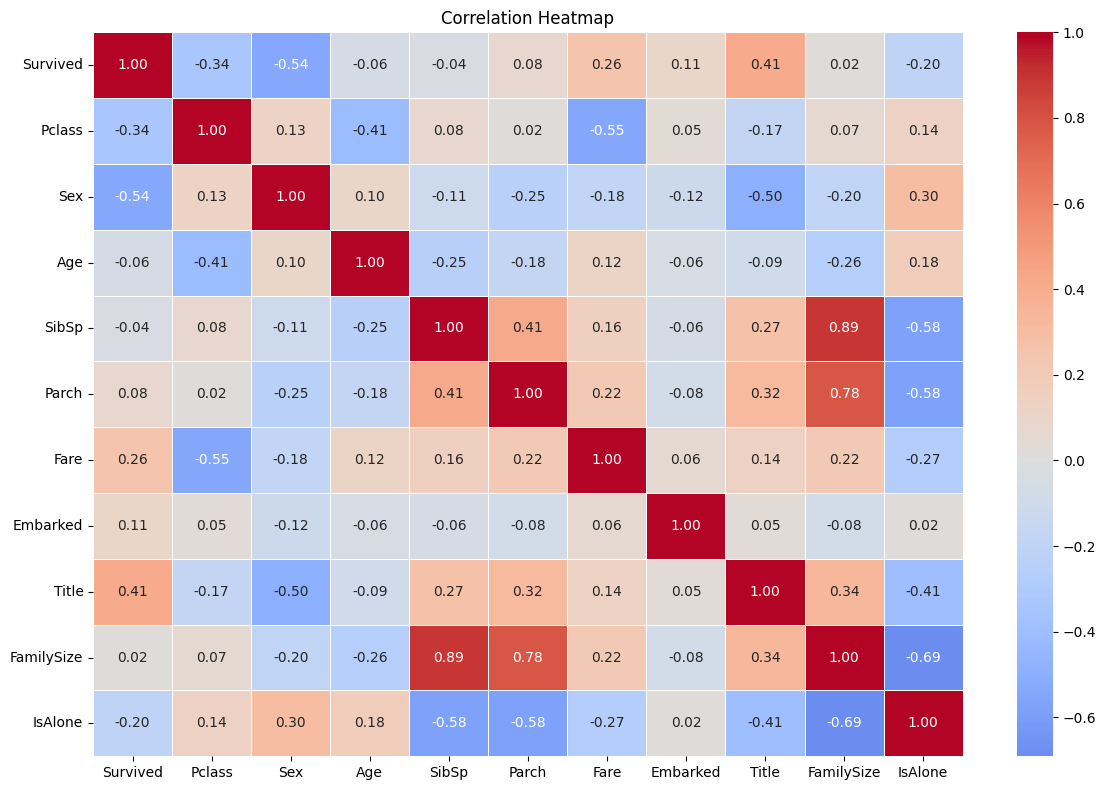


Interpretation:
Sex and Pclass have the strongest relationship with survival.
Women survived more often than men.
Passengers in higher classes had better survival chances.


In [30]:

print("\n================ Q1.6 — CORRELATION HEATMAP ================")


numeric_df = df[[
    'Survived',
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'Title',
    'FamilySize',
    'IsAlone'
]]

correlation_matrix = numeric_df.corr()

print("\nCorrelation with Survived:")
print(correlation_matrix['Survived']
      .sort_values(ascending=False))

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    center=0
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("Sex and Pclass have the strongest relationship with survival.")
print("Women survived more often than men.")
print("Passengers in higher classes had better survival chances.")



================ Q1.7 — LINEAR REGRESSION ================

Regression Coefficient:
-32.66051837394824

Intercept:
107.6056516220107


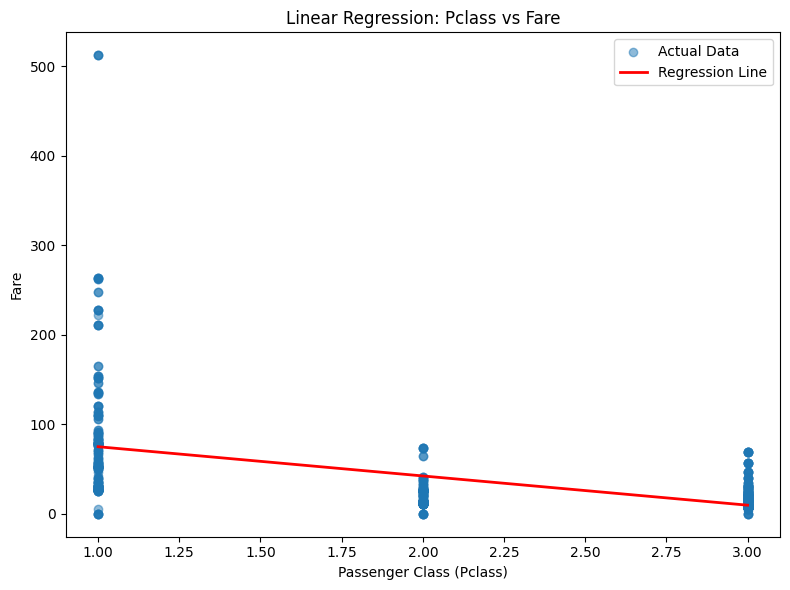


Interpretation:
Fare decreases as Pclass increases.
1st class passengers paid higher fares.
3rd class passengers paid lower fares.


In [31]:

print("\n================ Q1.7 — LINEAR REGRESSION ================")

# Input feature
X = df[['Pclass']]

# Target variable
y = df['Fare']

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

# Predictions
predicted_fare = model.predict(X)

# Print coefficient & intercept
print("\nRegression Coefficient:")
print(model.coef_[0])

print("\nIntercept:")
print(model.intercept_)

# Sort values for smooth line
sorted_index = df['Pclass'].argsort()

# Scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Pclass'],
    df['Fare'],
    alpha=0.5,
    label='Actual Data'
)

# Regression line
plt.plot(
    df['Pclass'].iloc[sorted_index],
    predicted_fare[sorted_index],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Fare')
plt.title('Linear Regression: Pclass vs Fare')

plt.legend()
plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
print("Fare decreases as Pclass increases.")
print("1st class passengers paid higher fares.")
print("3rd class passengers paid lower fares.")


In [32]:

print("\n================ Q1.8 — OUTLIER DETECTION ================")

# -------- IQR METHOD --------

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[
    (df['Fare'] < lower_bound) |
    (df['Fare'] > upper_bound)
]

print("\nIQR METHOD")
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(iqr_outliers))

print("\nTop 5 IQR Outliers:")
print(iqr_outliers[[
    'Name',
    'Pclass',
    'Fare',
    'Survived'
]].head())

# -------- Z-SCORE METHOD --------

z_scores = zscore(df['Fare'])

threshold = 3

zscore_outliers = df[
    np.abs(z_scores) > threshold
]

print("\nZ-SCORE METHOD")
print("Threshold:", threshold)
print("Number of Outliers:",
      len(zscore_outliers))

print("\nTop 5 Z-Score Outliers:")
print(zscore_outliers[[
    'Name',
    'Pclass',
    'Fare',
    'Survived'
]].head())



================ Q1.8 — OUTLIER DETECTION ================

IQR METHOD
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Outliers: 116

Top 5 IQR Outliers:
                                                 Name  Pclass      Fare  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...       1   71.2833   
27                     Fortune, Mr. Charles Alexander       1  263.0000   
31     Spencer, Mrs. William Augustus (Marie Eugenie)       1  146.5208   
34                            Meyer, Mr. Edgar Joseph       1   82.1708   
52           Harper, Mrs. Henry Sleeper (Myna Haxtun)       1   76.7292   

    Survived  
1          1  
27         0  
31         1  
34         0  
52         1  

Z-SCORE METHOD
Threshold: 3
Number of Outliers: 20

Top 5 Z-Score Outliers:
                                                Name  Pclass      Fare  \
27                    Fortune, Mr. Charles Alexander       1  263.0000   
88                        Fortune, Miss. Mabel Helen       1  263.0000   
1

In [33]:
print("\nComparison:")

print(f"IQR detected {len(iqr_outliers)} outliers.")
print(f"Z-score detected {len(zscore_outliers)} outliers.")

if len(iqr_outliers) > len(zscore_outliers):
    print("IQR detected more outliers.")
elif len(iqr_outliers) < len(zscore_outliers):
    print("Z-score detected more outliers.")
else:
    print("Both methods detected the same number of outliers.")


Comparison:
IQR detected 116 outliers.
Z-score detected 20 outliers.
IQR detected more outliers.


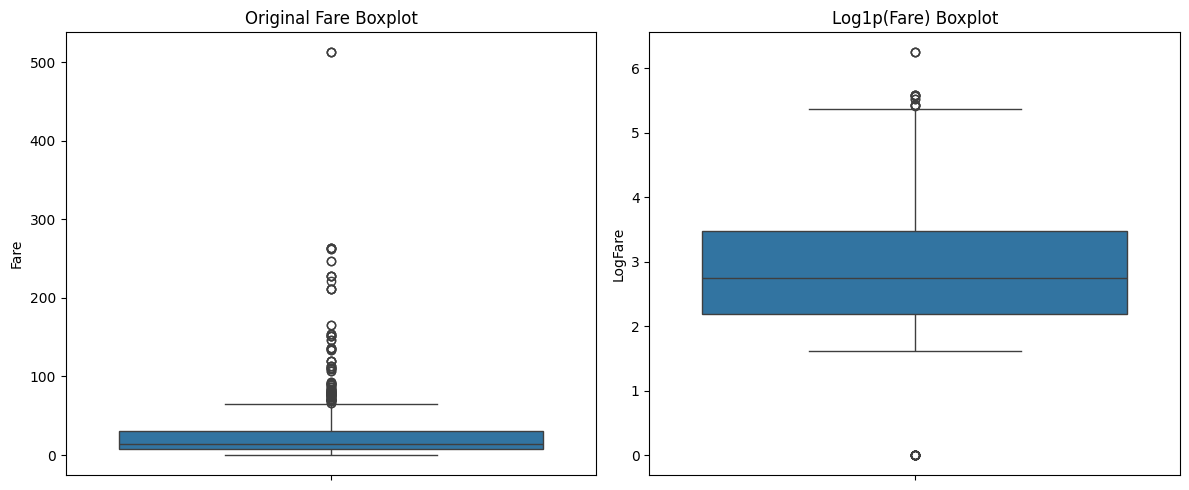

In [34]:
df['LogFare'] = np.log1p(df['Fare'])

plt.figure(figsize=(12, 5))

# Original Fare
plt.subplot(1, 2, 1)

sns.boxplot(y=df['Fare'])

plt.title('Original Fare Boxplot')

# Log transformed Fare
plt.subplot(1, 2, 2)

sns.boxplot(y=df['LogFare'])

plt.title('Log1p(Fare) Boxplot')

plt.tight_layout()
plt.show()